Сделаем нейронку на торче для fashion mnist


Для начала сделаем простенькое EDA

In [16]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}.")


train_dataset = datasets.FashionMNIST(
    root='../data/raw',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = datasets.FashionMNIST(
    root='../data/raw',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)


classes = train_dataset.classes
print(f'train_dataset shape: {len(train_dataset)}, image shape: {train_dataset[0][0].shape}')

Running on cuda.
train_dataset shape: 60000, image shape: torch.Size([1, 28, 28])


In [17]:
print(torch.version.cuda)

12.8


посмотрим пару картиночек

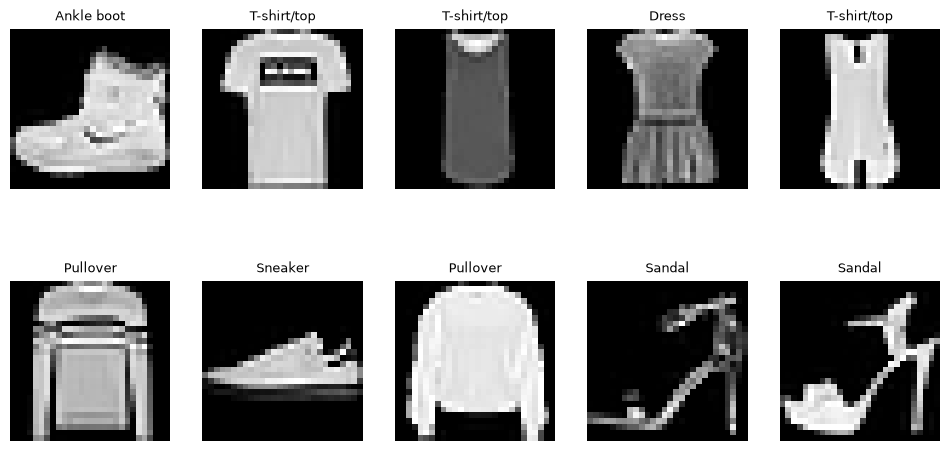

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[label], fontsize=9)
    ax.axis('off')
    
plt.tight_layout
plt.show()

In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [20]:
import torch.nn as nn 
from torchvision import models


class ModelFactory: 
    @staticmethod
    def get_model(name: str, num_classes: int = 10, in_channels: int = 1, pretrained: bool = False):
        weights = 'DEFAULT' if pretrained else None
        name = name.lower()
        
        if name == 'resnet18':
            model = models.resnet18(weights=weights)
            if in_channels != 3:
                model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
            return model 
        
        elif name == 'alexnet':
            model = models.alexnet(weights=weights)
            if in_channels != 3:
                model.features[0] = nn.Conv2d(in_channels, 64, kernel_size=4, stride=1, padding=2)
            model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
            return model
        
        elif name == 'vgg11':
            model = models.vgg11(weights=weights)
            if in_channels != 3: 
                model.features[0] = nn.Conv2d(in_channels, 64, kernel_size = 3, padding=1)
            model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
            return model
        else: 
            raise ValueError(f"model {name} not founded")

In [21]:
model = ModelFactory.get_model('resnet18', num_classes=10, in_channels=1, pretrained=False).to(device)

dummy_input = torch.randn(64, 1, 28, 28).to(device)
output = model(dummy_input)
print(f'output log size: {output.shape}')

output log size: torch.Size([64, 10])


In [22]:
class Trainer:
    def __init__(self, model, criterion, optimizer, device):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0
        
        for images, labels in dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        return total_loss / total, correct / total
    
    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                
        return total_loss / total, correct / total
    
    def fit(self, train_loader, test_loader, epochs=5):
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(test_loader)
            print(f'Эпоха [{epoch}/ {epochs}]')
            print(f'Train loss: {train_loss:.4f}, train acc: {train_acc:.4f}')
            print(f'test loss: {val_loss:.4f}, test acc {val_acc:.4f}')
        
            
            
            

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model = model,
                  criterion=criterion,
                  optimizer=optimizer,
                  device=device)

trainer.fit(train_loader, test_loader, epochs = 5)

Эпоха [1/ 5]
Train loss: 0.3594, train acc: 0.8703
test loss: 0.2940, test acc 0.8935
Эпоха [2/ 5]
Train loss: 0.2426, train acc: 0.9115
test loss: 0.2357, test acc 0.9153
Эпоха [3/ 5]
Train loss: 0.2048, train acc: 0.9253
test loss: 0.2284, test acc 0.9136
Эпоха [4/ 5]
Train loss: 0.1748, train acc: 0.9355
test loss: 0.2843, test acc 0.8969
Эпоха [5/ 5]
Train loss: 0.1536, train acc: 0.9436
test loss: 0.2205, test acc 0.9241
